plant_diease_detection_week1.ipynb


In [6]:
!pip install tensorflow-datasets

load the dataset(PlantVillage)

In [13]:
import tensorflow_datasets as tfds
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Requirement: Image Acquisition & Splitting
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'plant_village',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True
)

print(f"Dataset loaded. Classes: {ds_info.features['label'].num_classes}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.MKZR1P_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Dataset loaded. Classes: 38


EDA

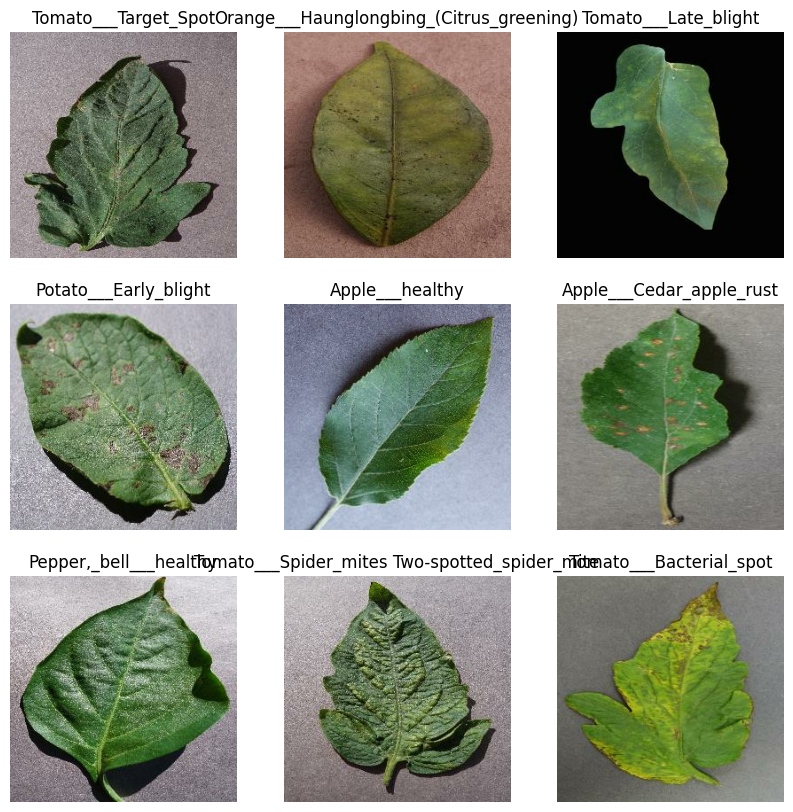

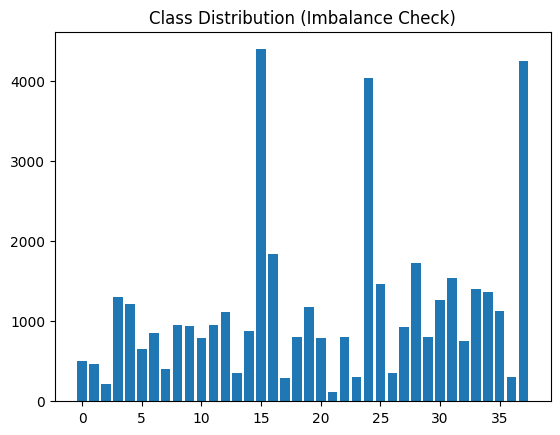

In [14]:
# Requirement: Plot sample images
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds_train.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(ds_info.features['label'].int2str(label))
    plt.axis("off")
plt.show()

# Requirement: Check for imbalances
import collections
labels = [label.numpy() for _, label in ds_train]
counter = collections.Counter(labels)
plt.bar(counter.keys(), counter.values())
plt.title("Class Distribution (Imbalance Check)")
plt.show()

Preprocessing


In [15]:
# Requirement: Handle lighting, dust, and variability
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomContrast(0.2),
])

def preprocess_image(image, label):
    # Requirement: "Standard dimension 224x224"
    image = tf.image.resize(image, (224, 224))
    # Requirement: "Normalize pixel arrays" (scales 0-255 to 0-1)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [16]:
BATCH_SIZE = 32

# Requirement: "Build an automated preprocessing pipeline"
train_ds = ds_train \
    .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE) \
    .cache() \
    .shuffle(1000) \
    .batch(BATCH_SIZE) \
    .map(lambda x, y: (data_augmentation(x, training=True), y)) \
    .prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds = ds_val \
    .map(preprocess_image) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = ds_test \
    .map(preprocess_image) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

print("Week 1 Engineering Roadmap Complete.")

Week 1 Engineering Roadmap Complete.
